In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.widgets import Button, Slider


## Example Slider Plot for Interactive Visualization

From [matplotlib documentation](https://matplotlib.org/stable/gallery/widgets/slider_demo.html).

Have a go editing the code below to see how it works. You can change the amplitude and frequency of the sine wave using the sliders. Change the button and slider names, remove sliders, etc.

In future, we could add a slider to control the `plot_line` parameter in the `plot_evolution_1D` function, allowing users to visualize the wavefield evolution at different positions along the grid.

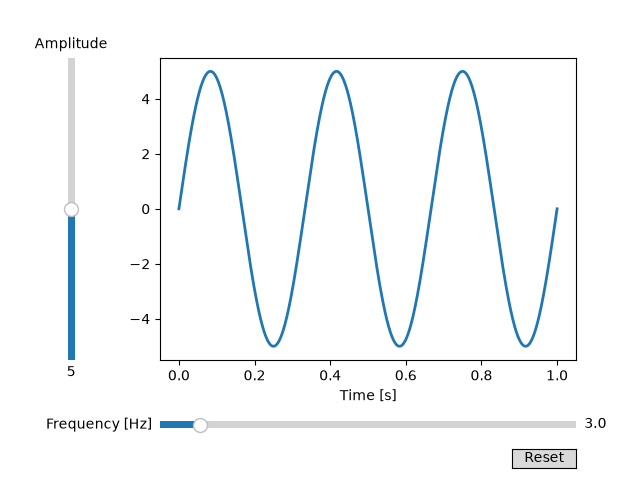

In [3]:

# The parametrized function to be plotted
def f(t, amplitude, frequency):
    return amplitude * np.sin(2 * np.pi * frequency * t)

t = np.linspace(0, 1, 1000)

# Define initial parameters
init_amplitude = 5
init_frequency = 3

# Create the figure and the line that we will manipulate
fig, ax = plt.subplots()
line, = ax.plot(t, f(t, init_amplitude, init_frequency), lw=2)
ax.set_xlabel('Time [s]')

# adjust the main plot to make room for the sliders
fig.subplots_adjust(left=0.25, bottom=0.25)

# Make a horizontal slider to control the frequency.
axfreq = fig.add_axes((0.25, 0.1, 0.65, 0.03))
freq_slider = Slider(
    ax=axfreq,
    label='Frequency [Hz]',
    valmin=0.1,
    valmax=30,
    valinit=init_frequency,
)

# Make a vertically oriented slider to control the amplitude
axamp = fig.add_axes((0.1, 0.25, 0.0225, 0.63))
amp_slider = Slider(
    ax=axamp,
    label="Amplitude",
    valmin=0,
    valmax=10,
    valinit=init_amplitude,
    orientation="vertical"
)


# The function to be called anytime a slider's value changes
def update(val):
    line.set_ydata(f(t, amp_slider.val, freq_slider.val))
    fig.canvas.draw_idle()


# register the update function with each slider
freq_slider.on_changed(update)
amp_slider.on_changed(update)

# Create a `matplotlib.widgets.Button` to reset the sliders to initial values.
resetax = fig.add_axes((0.8, 0.025, 0.1, 0.04))
button = Button(resetax, 'Reset', hovercolor='0.975')


def reset(event):
    freq_slider.reset()
    amp_slider.reset()
button.on_clicked(reset)

plt.show()
%matplotlib widget